In [45]:
import os
import gc
import sys
import json
import tifffile

import numpy as np
import scanpy as sc
import pandas as pd
import squidpy as sq

import pyro
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

from skimage.transform import rescale
from sklearn.neighbors import NearestNeighbors

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import rcParams

sns.set_context('paper')
# rcParams.update({'font.family': 'Arial'})
rcParams.update({'font.size': 12})
rcParams.update({'figure.dpi': 100})
rcParams.update({'savefig.dpi': 300})

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [47]:
sys.path.append('..')
sys.path.append('../models/')
sys.path.append('../util')

import plot, utils, trajectory, test_assoc
import vgae, configs, dataset

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
# Load paired Xenium & DESI
import IO, plot, utils, trajectory

xenium_path = '../data/NIH_F5/'
desi_path = '../data/NIH_F5/'
sample_id = 'NIH_F5'

adata_xenium = sc.read_h5ad(os.path.join(xenium_path, sample_id+'_xenium.h5'))
adata_he = sc.read_h5ad(os.path.join(desi_path, sample_id+'_desi.h5'))
adata_xenium, adata_he = IO.filter_cells(adata_xenium, adata_he, by='map')

sc.pp.filter_cells(adata_xenium, min_counts=20)
sc.pp.filter_genes(adata_xenium, min_cells=20)

if 'cell_type' in adata_xenium.obs.keys():
    adata_xenium.obs['leiden'], categories = adata_xenium.obs.cell_type.factorize()
    categories = categories.values
else:
    adata_norm = adata_xenium.copy()
    sc.pp.normalize_total(adata_norm)
    sc.pp.log1p(adata_norm)

    sc.pp.pca(adata_norm)
    sc.pp.neighbors(adata_norm)
    sc.tl.leiden(adata_norm, random_state=42)
    adata_xenium.obs['leiden'] = adata_norm.obs['leiden'].copy()
    del adata_norm   

# Dataset specs
n_subgraphs = 8
k = 8
r = 50

# Model parameters
n_hidden = 32
n_latent = 6

# Training parameters
n_epochs = 200
lr = 1e-2
patience = 20

cluster_key = 'cell_type'

# Model setup
graph_data = dataset.HeteroDataset(
    adatas_ref=adata_xenium, 
    adatas_query=adata_he,
    n_subgraphs=n_subgraphs, 
    k=k, r=r, is_weighted=True,
    cluster_key=cluster_key,
    alpha=1.0,

    # Update modality labels
    query='DESI', query_proj_key='xenium_map',
    ref='Xenium', ref_proj_key='spatial' 
)

train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

# Training & Inference
train_configs = configs.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience, 
    device=torch.device('cuda'),
)

model_configs = configs.set_model_configs(
    graph_data=graph_data,
    c_hidden=n_hidden, 
    c_latent=n_latent,
    c_aux=adata_he.shape[1],
    act=nn.SiLU(),
    infer_cell_interaction=True,
    ortho_lambda=1e-3,
) 


[2026-01-21 00:00:55] Constructing graph partitions from data 1
[2026-01-21 00:01:00] Constructing hetero-graph partitions from paired data 1


In [ ]:
# Dataset specs
n_subgraphs = 8
k = 8
r = 100

# Model parameters
n_hidden = 32
n_latent = 6

# Training parameters
n_epochs = 300
lr = 1e-3
patience = 500

data_path = '../data/breast/dcis_fov/'
outdir = '../figures/'
adata_xenium = sc.read_h5ad('../data/LYNX_xenium.h5ad')
# Drop observations whose cell_type contains 'hybrid' (case-insensitive)
mask_hybrid = adata_xenium.obs['cell_type'].astype(str).str.contains('hybrid', case=False, na=False)
if mask_hybrid.any():
    print(f"Dropping {mask_hybrid.sum()} cells with 'hybrid' in cell_type")
    adata_xenium = adata_xenium[~mask_hybrid].copy()
else:
    print("No 'hybrid' entries found in cell_type")

# Rename 'Prolif_Invasive_Tumor' -> 'Invasive_Tumor' and ensure categorical dtype
ct = adata_xenium.obs['cell_type'].astype(str).replace({'Prolif_Invasive_Tumor': 'Invasive_Tumor'})
adata_xenium.obs['cell_type'] = pd.Categorical(ct)

adata_he = sc.read_h5ad(os.path.join('../data/he_patches_norm.h5ad'))

interscetion = adata_xenium.obs_names.intersection(adata_he.obs_names)
adata_xenium = adata_xenium[interscetion].copy()
adata_he = adata_he[interscetion].copy()

cluster_key = 'cell_type'

# Filter out 'Unlabeled' cells & cells with extremely rare cell-types (DCIS2)
rare_labels = adata_xenium.obs[cluster_key].value_counts()[
    adata_xenium.obs[cluster_key].value_counts() < 10
].index.to_list()

labeled_mask = np.logical_and(
    adata_xenium.obs[cluster_key] != 'Unlabeled',
    ~adata_xenium.obs[cluster_key].isin(rare_labels)
)
adata_xenium = adata_xenium[labeled_mask].copy()
adata_xenium.obs.index = adata_xenium.obs.index.astype(int)
adata_he = adata_he[labeled_mask].copy()
patch_size = np.sqrt(adata_he.var.shape[0] // 3).astype(int)

del rare_labels, labeled_mask
gc.collect()

# Model setup
graph_data = dataset.HeteroDataset(
    adatas_ref=adata_xenium, 
    adatas_query=adata_he,
    n_subgraphs=n_subgraphs, 
    k=k, r=r, is_weighted=True,
    cluster_key=cluster_key,
    alpha=2.0,

    # Update modality labels
    query='HE', query_proj_key='spatial',
    ref='Xenium', ref_proj_key='spatial' 
)

train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

# Training & Inference
train_configs = configs.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience, 
    device=torch.device('cuda'),
)

model_configs = configs.set_model_configs(
    graph_data=graph_data,
    c_hidden=n_hidden, 
    c_latent=n_latent,
    patch_size=patch_size,
    act=nn.SiLU(),
    infer_cell_interaction=True,
    ortho_lambda=1e-3,
) 


Dropping 135 cells with 'hybrid' in cell_type


In [92]:
import torch
import pandas as pd

# Global cell type coding from full AnnData
cat = pd.Categorical(adata_xenium.obs["cell_type"])
ct_names = list(cat.categories)

# Keep this on CPU for cheap indexing; we'll move to device per batch if needed
codes_adata_cpu = torch.tensor(cat.codes, dtype=torch.long)  # [N_adata]
C = len(ct_names)

# Global accumulator
counts_total = torch.zeros((C, C), dtype=torch.long)

for b, data in enumerate(train_data):
    edge_index = data[("Xenium", "to", "Xenium")].edge_index
    src, dst = edge_index[0], edge_index[1]

    # map Xenium nodes in THIS batch back to global adata indices
    xenium_idx = data["Xenium"].idx.to(torch.long).cpu()   # [N_graph_this_batch]
    codes = codes_adata_cpu[xenium_idx]                    # [N_graph_this_batch]

    # edge endpoint celltypes
    src_ct = codes[src.cpu()]
    dst_ct = codes[dst.cpu()]

    # bincount pairs (src_type -> dst_type)
    pair = src_ct * C + dst_ct
    counts_b = torch.bincount(pair, minlength=C * C).reshape(C, C)

    counts_total += counts_b

# Make table
ct_ct_df = pd.DataFrame(
    counts_total.numpy(),
    index=ct_names,     # rows = SOURCE type
    columns=ct_names    # cols = TARGET type
)

ct_ct_df


,Cholangiocytes + Progenitor,Endothelial,Fibroblasts,Hepatocytes,Kupffer,M2 Macrophages,Sinusoidal,Smooth Muscle cells,T-cells
Cholangiocytes + Progenitor,0,2209,11530,9913,788,274,717,3012,374
Endothelial,2209,0,8182,16491,735,491,1171,2719,569
Fibroblasts,11530,8182,0,103003,4210,6114,11190,24498,5310
Hepatocytes,9913,16491,103003,0,12304,40981,71348,9654,26813
Kupffer,788,735,4210,12304,0,778,1428,631,711
M2 Macrophages,274,491,6114,40981,778,0,5079,131,2045
Sinusoidal,717,1171,11190,71348,1428,5079,0,353,3208
Smooth Muscle cells,3012,2719,24498,9654,631,131,353,0,466
T-cells,374,569,5310,26813,711,2045,3208,466,0


In [93]:
import torch

incoming_all = []  # store per-node incoming degrees across batches

for data in train_data:
    edge_index = data[("Xenium", "to", "Xenium")].edge_index
    dst = edge_index[1]  # target nodes

    N = data["Xenium"].num_nodes
    incoming_deg = torch.bincount(dst.cpu(), minlength=N)  # incoming per node in this batch
    incoming_all.append(incoming_deg)

incoming_all = torch.cat(incoming_all)  # pooled over all batch nodes

print("Incoming edges per Xenium node (pooled across batches):")
print(f"  min  = {incoming_all.min().item()}")
print(f"  mean = {incoming_all.float().mean().item():.2f}")
print(f"  max  = {incoming_all.max().item()}")


Incoming edges per Xenium node (pooled across batches):
  min  = 0
  mean = 16.83
  max  = 89


Epoch 199 train -ELBO: 167.651; val -ELBO: 162.372; val R2: 0.497; q(z) corr: 0.378; p(z) corr: 0.649: 100%|██████████| 200/200 [18:14<00:00,  5.47s/it]


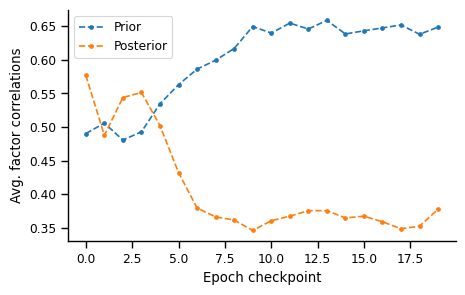

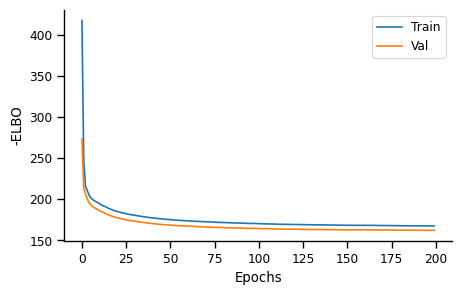

In [123]:
pyro.clear_param_store()
torch.cuda.empty_cache()

model = vgae.HeteroAttnVGAE(model_configs, device=torch.device('cuda'))
model.fit(graph_data, train_configs, DEBUG=True)
res = model.evaluate(
    adata_xenium, adata_he,
    graph_data=graph_data,
    device=torch.device('cpu'),
)

In [139]:
res = model.evaluate(
    adata_xenium, adata_he,
    graph_data=graph_data,
    device=torch.device('cpu'),
)

(2, 6)
(20, 6)
Computing pseudotime on principal curve...


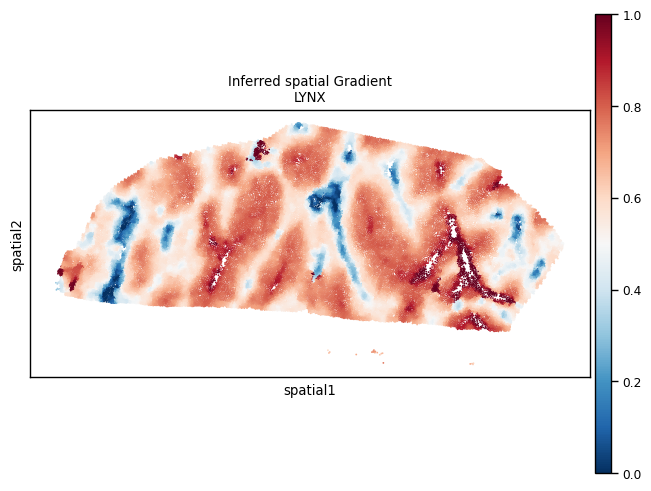

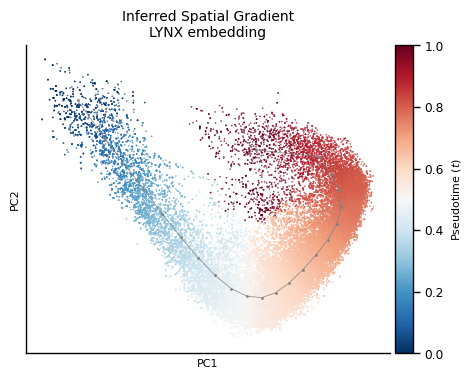

In [140]:
# (i). Trajectory Inference
# Xenium gradient 
curve = trajectory.get_curve(adata_xenium, epg_lambda=0.01, trim_radius_ratio=0.5)
trajectory.compute_pseudotime(adata_xenium, curve, root_marker='DPT')

sq.pl.spatial_scatter(
    adata_xenium, color='t', 
    cmap='RdBu_r', size=25, img=False,
    title='Inferred spatial Gradient\nLYNX'
)

plot.disp_trajectory(
    adata_xenium, 
    cmap='RdBu_r',
    title='Inferred Spatial Gradient\nLYNX embedding'
)

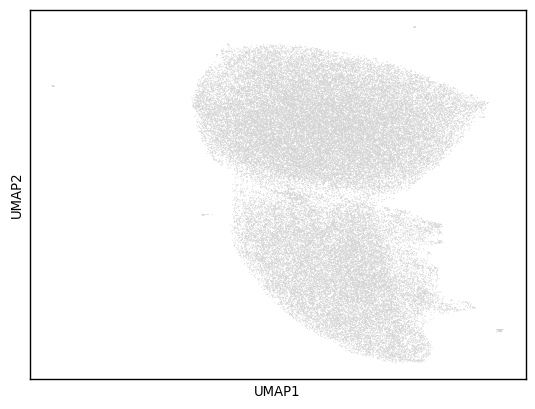

In [136]:
adata_xenium.obsm['X_z'] = res.qs

sc.pp.neighbors(adata_xenium, use_rep='X_z')
sc.tl.umap(adata_xenium)
sc.pl.umap(adata_xenium)

(2, 6)
(20, 6)
Computing pseudotime on principal curve...


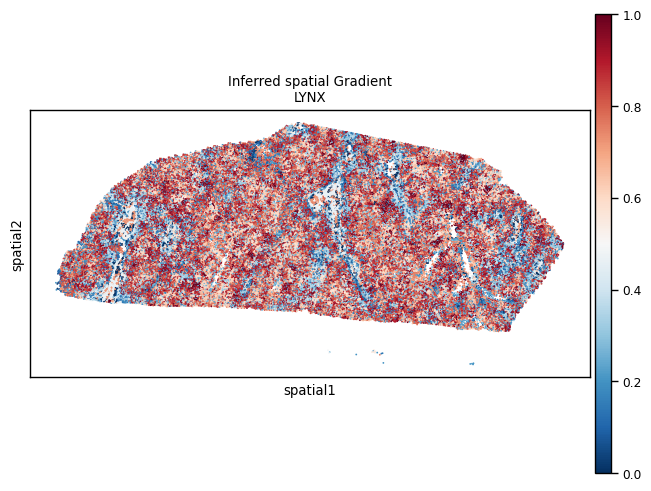

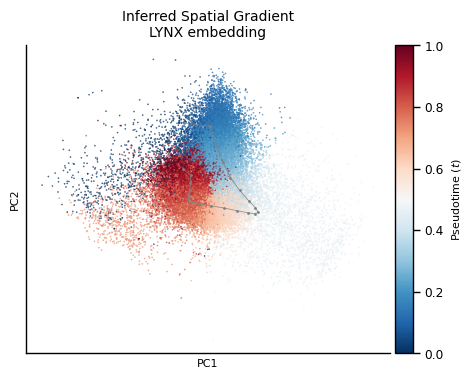

In [64]:
# (i). Trajectory Inference
# Xenium gradient 
curve = trajectory.get_curve(adata_xenium, epg_lambda=0.01, trim_radius_ratio=0.5)
trajectory.compute_pseudotime(adata_xenium, curve, root_marker='DPT')

sq.pl.spatial_scatter(
    adata_xenium, color='t', 
    cmap='RdBu_r', size=25, img=False,
    title='Inferred spatial Gradient\nLYNX'
)

plot.disp_trajectory(
    adata_xenium, 
    cmap='RdBu_r',
    title='Inferred Spatial Gradient\nLYNX embedding'
)

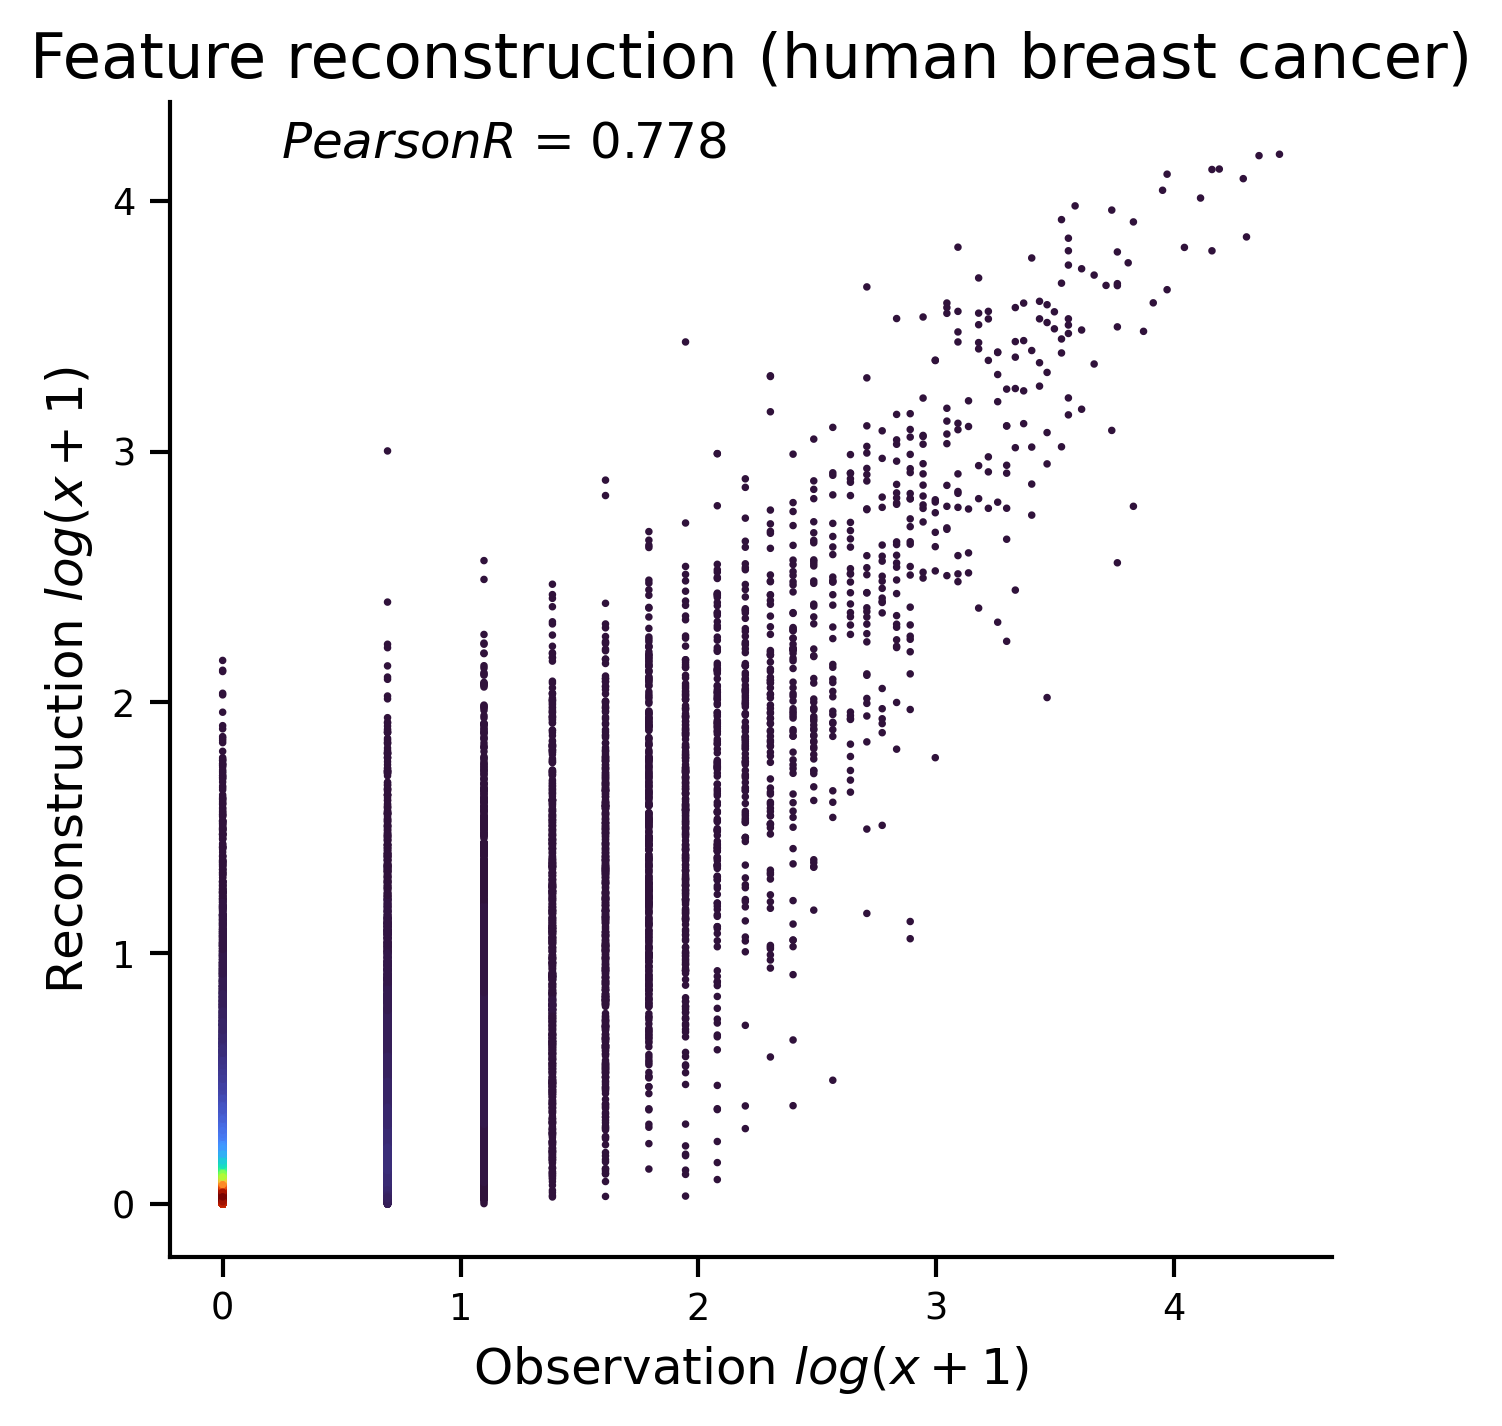

13820

In [24]:
plot.disp_kde_scatter(
    adata_xenium.X.A.flatten().copy(),
    res.px.flatten().copy(),
    xlabel=r"Observation $log(x+1)$",
    ylabel=r"Reconstruction $log(x+1)$",
    title='Feature reconstruction (human breast cancer)'
)
gc.collect()

In [ ]:
# np.save('../results/breast/LYNX_latent_6.npy', adata_xenium.obsm['X_z'])
# np.save('../results/breast/LYNX_pseudotime_6.npy', adata_xenium.obs['t'])
# adata_xenium.write_h5ad('../results/breast/LYNX_xenium.h5ad')

#### Downstream tree analysis

In [ ]:
# Load saved latent embedding
adata_xenium.obsm['X_z'] = np.load('../results/breast/LYNX_latent_6.npy').astype(np.float32)

adata_tmp = sc.read_h5ad('../results/breast/LYNX_xenium.h5ad')
adata_xenium.obsm['omega'] = adata_tmp.obsm['omega'].copy()
adata_xenium.obsm['abundance'] = adata_tmp.obsm['abundance'].copy()
adata_xenium.uns['edge_index'] = adata_tmp.uns['edge_index'].copy()
adata_xenium.uns['omega'] = adata_tmp.uns['omega'].copy()

del adata_tmp
gc.collect()

---

    graph cleaned --> removed 11 principal points


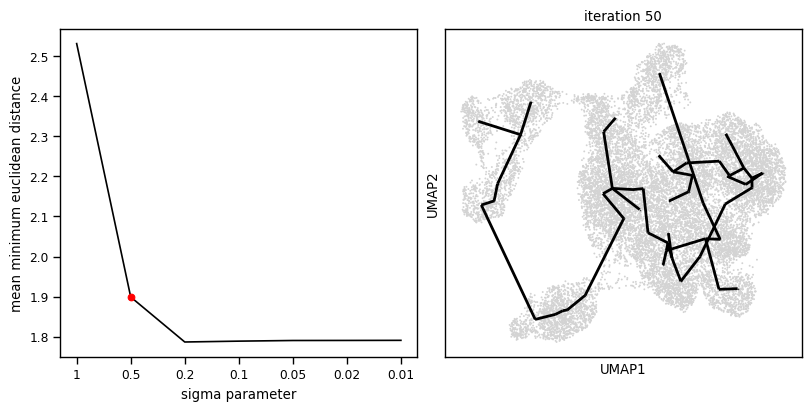

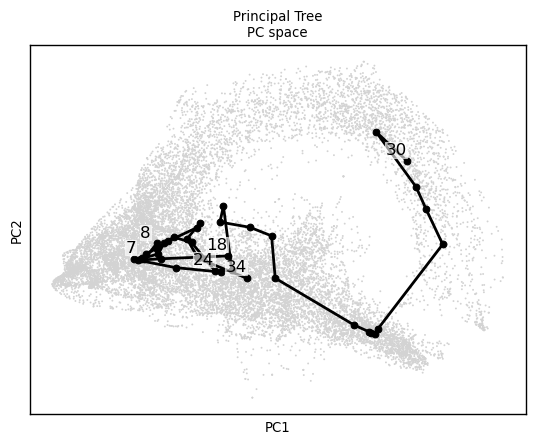

In [44]:
# ppt_sigma = scf.tl.explore_sigma(
#     adata_xenium,
#     Nodes=50,
#     use_rep="X_z",
#     nsteps=50,
#     lambda_=10,
#     sigmas=[1, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01],
#     seed=42,
#     plot=True
# )
# print("Selected sigma:", ppt_sigma)
# scf.tl.cleanup(adata_xenium, minbranchlength=5)
# scf.pl.graph(adata_xenium, basis='pca')

# principal_graph = adata_xenium.uns['graph']
# tips = principal_graph['tips']
# forks = principal_graph['forks']
# print(tips, forks)

# scf.tl.root(adata_xenium, 25)
# scf.tl.pseudotime(adata_xenium, n_jobs=20, seed=42)

# t = adata_xenium.obs['t'].values
# adata_xenium.obs['t'] = (t - t.min()) / (t.max() - t.min())
# del t

principal_graph = trajectory.get_tree(
    adata_xenium,
    use_rep='X_z',
    n_nodes=50,
    plot_graph=True
)


In [33]:
principal_graph['tips']

array([11, 19, 26, 28, 30])

In [29]:
principal_graph['forks']

array([ 3, 14, 40])

In [26]:
# From the principal tree visualization, we assign the root node as 25
trajectory.compute_pseudotime(adata_xenium, principal_graph, source=25)

Computing pseudotime on principal tree...
node 25 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    finished (0:00:11) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


In [ ]:
# sc.set_figure_params(scanpy=True, dpi_save=300, fontsize=10)
# rcParams.update({'font.size': 12})
# scf.pl.graph(
#     adata_xenium, tips=False, forks=False, basis='pca', 
#     title='Principal graph',
#     save='LYNX_Fig4_pc_tree.pdf'
# )

We can now further extract principal tree segments w.r.t the branching points:
- (1). root to branching point (fork)
- (2). fork to leaves

In [27]:
root_path = trajectory.sort_nodes(
    adata_xenium, root_node=25, term_node=9
)

dcis_path = trajectory.sort_nodes(
    adata_xenium, root_node=9, term_node=19
)[1:]   # Avoid repeating the branching node

invasive_path = trajectory.sort_nodes(
    adata_xenium, root_node=9, term_node=6
)[1:]   # Avoid repeating the branching node


IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
segments = []
principal_assignments = adata_xenium.obsm['X_R'].argmax(1)
for i, assign in enumerate(principal_assignments):
    if assign in root_path:
        segments.append('root')
    elif assign in dcis_path:
        segments.append('dcis')
    else:
        segments.append('invasive')

adata_xenium.obs['milestones'] = segments
adata_xenium.obs['seg'] = pd.Categorical(segments).codes

fig, ax = plt.subplots(dpi=300)
sc.pl.pca(
    adata_xenium, color=['milestones'],
    ax=ax, title='', show=False)
ax.set_title('Principal graph hub assignment', fontsize=12)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_pc_hub.pdf'), bbox_inches='tight')

---

In [ ]:
# sc.tl.umap(adata_xenium, n_components=3)
# scf.pl.trajectory_3d(adata_xenium, basis='umap', color='milestones')

Spatial visualizations:

In [ ]:
fig, ax = plt.subplots(dpi=300)
sc.pl.pca(adata_xenium, color='t', ax=ax, title='', cmap='RdBu_r', show=False)
ax.set_title('Inferred spatial gradient\nLYNX latent embedding', fontsize=12)
cb = plt.gcf().axes[-1]
cb.set_ylabel(r'Pseudotime $(t)$', fontsize=8)
plt.show()
fig.savefig(os.path.join(outdir, 'LYNX_Fig4_pc_pseudotime.pdf'), bbox_inches='tight')

fig, ax = plt.subplots(dpi=300)
sq.pl.spatial_scatter(
    adata_xenium, 
    color='t', cmap='RdBu_r',
    size=20, img=False, edgecolor='none', 
    ax=ax, return_ax=True, title='',
)
cb = plt.gcf().axes[-1]
cb.set_ylabel(r'Pseudotime $(t)$', fontsize=8)
ax.set_title('Inferred spatial gradient', fontsize=12)
plt.show()
fig.savefig(os.path.join(outdir, 'LYNX_Fig4_spatial_pseudotime.pdf'), bbox_inches='tight')

In [ ]:
# sc.set_figure_params(scanpy=True, fontsize=10)
fig, ax = plt.subplots(dpi=300)
sq.pl.spatial_scatter(
    adata_xenium, color='cell_type',
    img=False, size=20, ax=ax, return_ax=True,
    title=''
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_spatial.pdf'), bbox_inches='tight')

sc.set_figure_params(scanpy=True, fontsize=10)
fig, ax = plt.subplots(dpi=300)
sc.pl.pca(
    adata_xenium, 
    color='cell_type', 
    groups=['Stromal', 'DCIS_1', 'Invasive_Tumor'],
    na_in_legend=False,
    legend_loc="on data",
    legend_fontsize=6,
    ax=ax, title='', show=False)
ax.set_title('Stromal & tumor cell distributions\n'+'LYNX latent embedding', fontsize=12)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_pc_tumor.pdf'), bbox_inches='tight')

fig, ax = plt.subplots(dpi=300)
sc.pl.pca(
    adata_xenium, 
    color='cell_type', 
    groups=[
        'B_Cells',
        'CD4+_T_Cells',
        'CD8+_T_Cells',
        'IRF7+_DCs',
        'LAMP3+_DCs',
        'Macrophages_1',
        'Macrophages_2',
        'Mast_Cells',           
    ],
    na_in_legend=False,
    ax=ax, title='', show=False)
ax.set_title('Immune cell distributions\n'+r'LYNX latent embedding', fontsize=12)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_pc_immune.pdf'), bbox_inches='tight')


**[Case study]**

Cluster stromal cells based on assignments w.r.t. subtree:

In [ ]:
adata_norm = adata_xenium.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)


In [ ]:
stromal_states = np.array(['NA']*len(adata_xenium)).astype('>U20')
stromal_states[
    np.logical_and(
        adata_xenium.obs[cluster_key] == 'Stromal',
        adata_xenium.obs['milestones'] == 'invasive'
    )
] = 'Invasive_adjacent'

stromal_states[
    np.logical_and(
        adata_xenium.obs[cluster_key] == 'Stromal',
        adata_xenium.obs['milestones'] == 'dcis'
    )
] = 'DCIS_adjacent'

stromal_states[
    np.logical_and(
        adata_xenium.obs[cluster_key] == 'Stromal',
        adata_xenium.obs['milestones'] == 'root'
    )
] = 'Root_adjacent'

adata_xenium.obs['stromal_state'] = stromal_states
fig, ax = plt.subplots(dpi=300)
sc.pl.pca(
    adata_xenium, color='stromal_state',
    groups=['DCIS_adjacent', 'Invasive_adjacent', 'Root_adjacent'],
    na_in_legend=False, ax=ax, title='', show=False)
ax.set_title('Stromal state assignment', fontsize=12)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_pc_stromal_state.pdf'), bbox_inches='tight')

In [ ]:
# Remove duplicate columns
if any(adata_xenium.obs.columns.duplicated()):
    print(f"Removing duplicate columns: {adata_xenium.obs.columns[adata_xenium.obs.columns.duplicated()].tolist()}")
    adata_xenium.obs = adata_xenium.obs.loc[:, ~adata_xenium.obs.columns.duplicated()]

adata_xenium.obs_names = adata_xenium.obs.index.astype(str)
adata_stromal = adata_xenium[adata_xenium.obs['cell_type'] == 'Stromal'].copy()
sc.pp.normalize_total(adata_stromal, target_sum=1e4)
sc.pp.log1p(adata_stromal)
sc.pp.scale(adata_stromal)
sc.tl.rank_genes_groups(adata_stromal, groupby="stromal_state", method="wilcoxon")
sc.pl.rank_genes_groups(adata_stromal, n_genes=10, sharey=False)

dcis_stromal_markers = sc.get.rank_genes_groups_df(adata_stromal, group='DCIS_adjacent').head(10).names.to_list()
invasive_stromal_markers = sc.get.rank_genes_groups_df(adata_stromal, group='Invasive_adjacent').head(10).names.to_list()

sc.set_figure_params(scanpy=True, dpi_save=300, fontsize=10)
fig, ax = plt.subplots(figsize=(6, 2.5), dpi=300)
sc.pl.rank_genes_groups_matrixplot(
    adata_stromal, groupby="stromal_state", # values_to_plot='logfoldchanges',
    dendrogram=False, n_genes=5, cmap='RdBu_r',
    ax=ax, show=False
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_stromal_marker_heatmap.pdf'), bbox_inches='tight')

In [ ]:
# PC visualization of stromal markers
dcis_stromal_markers = sc.get.rank_genes_groups_df(adata_stromal, group='DCIS_adjacent').head(10).names.to_list()
invasive_stromal_markers = sc.get.rank_genes_groups_df(adata_stromal, group='Invasive_adjacent').head(10).names.to_list()

sc.pl.pca(
    adata_stromal, color=dcis_stromal_markers+invasive_stromal_markers,
    ncols=5, title='', show=True
)

del adata_stromal
gc.collect()

In [ ]:
sc.pl.pca(adata_norm, color=['CXCL12', 'CXCR4'], cmap='magma')

**Cell-type & feature dynamics along different segments**

In [ ]:
from scipy.interpolate import UnivariateSpline
from typing import Iterable

def disp_tree_dynamics(
    dynamic_dfs, labels, feature, colors,
    std_dfs=None, ylabel='Expression', 
    spline_factor=1e-3, dpi=100, figsize=(6, 3),
    milestone_assignments=None, milestone_cmap='Set3'
):
    r"""
    Plot tree dynamics with optional milestone colorbar.
    """
    assert len(dynamic_dfs) == len(labels)
    if isinstance(colors, Iterable) and not isinstance(colors, str):
        assert len(colors) == len(dynamic_dfs)
    
    n_bins = dynamic_dfs[0].shape[0]

    # Adjust figure layout if milestones are provided
    if milestone_assignments is not None:
        fig = plt.figure(figsize=figsize, dpi=dpi)
        
        # Create main plot with space for milestone colorbar
        ax = plt.subplot2grid((12, 1), (0, 0), rowspan=8)
        milestone_ax = plt.subplot2grid((10, 1), (9, 0), rowspan=1)
    else:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Plot trajectories
    for i, df in enumerate(dynamic_dfs):
        x = np.arange(n_bins)
        y = df[feature]
        
        color = colors[i] if isinstance(colors, (list, tuple)) else colors
    
        if std_dfs is None:
            # Spline regression
            spline = UnivariateSpline(x, y, s=len(x)*spline_factor) 
            xx = np.linspace(x.min(), x.max(), 500)
            yy = spline(xx)
            
            # Compute residuals and standard deviation for uncertainty
            y_pred = spline(x)
            residuals = y - y_pred
            std_residual = np.std(residuals)
            
            # Plot with uncertainty bands
            ax.scatter(x, y, s=5, c=color, label=labels[i])
            ax.plot(xx, yy, linewidth=1, c=color)
            ax.fill_between(xx, yy - std_residual, yy + std_residual, 
                    color=color, alpha=0.5)
        else:
            ax.plot(x, y, linewidth=2, color=color, linestyle='-.', label=labels[i])
            ax.fill_between(x, y-std_dfs[i][feature], y+std_dfs[i][feature], 
                          color=color, alpha=0.5)

    ax.grid(False)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.spines[['right', 'top']].set_visible(False)
    ax.legend()
    ax.set_title(feature, fontsize=15)
    
    # Add milestone colorbar if provided
    if milestone_assignments is not None:
        # Create milestone colorbar
        unique_milestones = np.unique(milestone_assignments)
        n_milestones = len(unique_milestones)
        
        # Create colormap and normalization
        milestone_colors = plt.cm.get_cmap(milestone_cmap, n_milestones)
        milestone_to_idx = {milestone: i for i, milestone in enumerate(unique_milestones)}
        
        # Create array for colorbar
        milestone_indices = np.array([milestone_to_idx[m] for m in milestone_assignments])
        
        # Plot milestone assignments as image - align with scatter point positions
        milestone_ax.imshow(
            milestone_indices.reshape(1, -1), 
            aspect='auto', 
            cmap=milestone_colors,
            extent=[-0.5, n_bins-0.5, 0, 1]  # Changed from [0, n_bins] to [-0.5, n_bins-0.5]
        )
        
        # Configure milestone axis
        milestone_ax.set_xlim(-0.5, n_bins-0.5)  # Match the scatter point range
        milestone_ax.set_ylim(0, 1)
        milestone_ax.set_xticks([])
        milestone_ax.set_yticks([])
        
        # Add milestone labels
        milestone_positions = []
        milestone_labels = []
        for milestone in unique_milestones:
            milestone_mask = milestone_assignments == milestone
            if np.any(milestone_mask):
                # Find center position of this milestone
                indices = np.where(milestone_mask)[0]
                center_pos = (indices[0] + indices[-1]) / 2
                milestone_positions.append(center_pos)
                milestone_labels.append(milestone)
        
        # Add text labels for milestones
        for pos, label in zip(milestone_positions, milestone_labels):
            milestone_ax.text(pos, 0.5, label, ha='center', va='center', 
                            fontsize=8, fontweight='bold')
        
        # Remove x-axis label from main plot
        ax.set_xlabel(r'Pseudotime (root $\rightarrow$ tumor bins)')
        ax.set_xticks(np.arange(0, n_bins, n_bins//5))
        
        # Add colorbar title
        milestone_ax.set_title('', pad=5)
        
        # Match x-axis limits between main plot and colorbar
        ax.set_xlim(-0.5, n_bins-0.5)
        
    else:
        ax.set_xlabel(r'Pseudotime (root $\rightarrow$ tumor bins)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

In [ ]:
# Compute smoothed trajectory seg assignments
n_bins = 50
smoothed_t = utils.get_binned_expr(
    pd.DataFrame(adata_xenium.obs['t'].sort_values()).T,
    n_bins=n_bins
).values.flatten()
t_threshold = adata_xenium[adata_xenium.obs['milestones'] == 'root'].obs['t'].max()
milestone_assignments = np.where(smoothed_t < t_threshold, 'root', 'tumor')
del smoothed_t, t_threshold

In [ ]:
adata_invasive = adata_norm.copy()
adata_invasive.obs_names = adata_invasive.obs_names.astype(str)
adata_invasive = adata_invasive[adata_invasive.obs['milestones'].isin(['root', 'invasive'])].copy()
invasive_dynamic_df = utils.get_celltype_dynamics(adata_invasive, adata_invasive.obs['cell_type'], n_bins=n_bins)

# Cell-typ dynamics towards DCIS
adata_dcis = adata_norm.copy()
adata_dcis.obs_names = adata_dcis.obs_names.astype(str)
adata_dcis = adata_dcis[adata_dcis.obs['milestones'].isin(['root', 'dcis'])].copy()
dcis_dynamic_df = utils.get_celltype_dynamics(adata_dcis, adata_dcis.obs['cell_type'], n_bins=n_bins)

cluster_labels = adata_xenium.obs[cluster_key].cat.categories.to_list()
for label in cluster_labels:
    if label in invasive_dynamic_df.columns and label in dcis_dynamic_df.columns:
        disp_tree_dynamics(
            dynamic_dfs=[dcis_dynamic_df, invasive_dynamic_df],
            labels=['DCIS_trajectory', 'Invasive_trajectory'],
            ylabel='Proportion', colors=['mediumblue', 'coral'],
            feature=label
        )

del label
gc.collect()


In [ ]:
fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_dynamic_df, invasive_dynamic_df],
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    ylabel='Proportion', colors=['mediumblue', 'coral'],
    feature='CD8+_T_Cells', milestone_assignments=milestone_assignments, 
    dpi=300
)
plt.show()
#fig.savefig(os.path.join(outdir, 'LYNX_Fig4_cd8_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_dynamic_df, invasive_dynamic_df],
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    ylabel='Proportion', colors=['mediumblue', 'coral'],
    feature='Macrophages_2', milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_m2_dynamics.pdf'), bbox_inches='tight')

gc.collect()

In [ ]:
# Gene expression dynamics along DCIS vs Invasive trajectories
indices = np.argsort(adata_dcis.obs['t'].values)
dcis_gexp_df, dcis_gexp_std_df = utils.get_binned_expr(
    adata_dcis.to_df().iloc[indices].T,
    n_bins=n_bins,
    std=True
)

indices = np.argsort(adata_invasive.obs['t'].values)
invasive_gexp_df, invasive_gexp_std_df = utils.get_binned_expr(
    adata_invasive.to_df().iloc[indices].T,
    n_bins=n_bins,
    std=True
)

# Visualization
fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_gexp_df, invasive_gexp_df],
    # std_dfs=[dcis_gexp_std_df, invasive_gexp_std_df],
    feature='GJB2', spline_factor=.1,
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
fig.savefig(os.path.join(outdir, 'LYNX_Fig4_gjb2_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_gexp_df, invasive_gexp_df],
    # std_dfs=[dcis_gexp_std_df, invasive_gexp_std_df],
    feature='SFRP4',spline_factor=.1,
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
fig.savefig(os.path.join(outdir, 'LYNX_Fig4_sfrp4_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_gexp_df, invasive_gexp_df],
    # std_dfs=[dcis_gexp_std_df, invasive_gexp_std_df],
    feature='CXCL12', spline_factor=.1,
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
fig.savefig(os.path.join(outdir, 'LYNX_Fig4_cxcl12_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_gexp_df, invasive_gexp_df],
    # std_dfs=[dcis_gexp_std_df, invasive_gexp_std_df],
    feature='CXCR4', spline_factor=.1,
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
fig.savefig(os.path.join(outdir, 'LYNX_Fig4_cxcr4_dynamics.pdf'), bbox_inches='tight')

gc.collect()

**[Case study]**

Stromal subset marker dynamics:

In [ ]:
# Comparison of fibroblast signatures

myCAF_markers = [
    "APOD",
    "DCN",
    "PTGDS",
    "CFD",
    "LUM",
    "C1S",
    "CXCL12",
    "C3",
    "SFRP2",
    "CXCL14",
    "CCDC80",
    "MFAP4",
    "FBLN1",
    "GSN",
    "CTSK",
    "SERPINF1",
    "RARRES2",
    "SFRP4",
    "C1R",
    "IGF2",
    "CYR61",
    "CTGF",
    "SERPING1",
    "IGFBP6",
    "MMP2",
    "IGFBP4",
    "COL6A2",
    "MEG3",
    "IGF1",
    "SRPX",
    "COL3A1",
    "AEBP1"
]

iCAF_markers = [
    "COL1A1",
    "COL1A2",
    "COL3A1",
    "LUM",
    "SFRP2",
    "POSTN",
    "MMP11",
    "CTHRC1",
    "FN1",
    "SPARC",
    "DCN",
    "COL6A3",
    "BGN",
    "COL6A2",
    "COL6A1",
    "CTGF",
    "AEBP1",
    "COL5A2",
    "VCAN",
    "CTSK",
    "RARRES2",
    "TIMP1",
    "CCDC80",
    "MMP2",
    "SFRP4",
    "CXCL14",
    "ASPN",
    "THY1",
    "MFAP2",
    "C1S",
    "SERPINF1"
]
CAF_markers = list(set(myCAF_markers + iCAF_markers))
CAF_markers = [gene for gene in CAF_markers if gene in adata_xenium.var_names]
del myCAF_markers, iCAF_markers


PVL_diff_markers = [
    "ACTA2",
    "TAGLN",
    "MYL9",
    "TPM2",
    "NDUFA4L2",
    "SOD3",
    "ADIRF",
    "MYH11",
    "RGS5",
    "RERGL",
    "IGFBP7",
    "CALD1",
    "SPARCL1",
    "MT1M",
    "C11orf96",
    "PPP1R14A",
    "MFGE8",
    "PLAC9",
    "DSTN",
    "PTP4A3",
    "MCAM",
    "SORBS2",
    "COL18A1",
    "TINAGL1",
    "CAV1",
    "TPM1",
    "MT1E",
    "PLN",
    "CSRP2",
    "PRKCDBP",
    "MYLK"
]

PVL_immature_markers = [
    "CCL19",
    "RGS5",
    "IGFBP7",
    "NDUFA4L2",
    "CCL2",
    "CCL21",
    "COL18A1",
    "CALD1",
    "LHFP",
    "THY1",
    "CPE",
    "MYL9",
    "SPARC",
    "COL4A1",
    "TAGLN",
    "STEAP4",
    "ACTA2",
    "COL4A2",
    "TIMP1",
    "IGFBP5",
    "NOTCH3",
    "PDGFRB",
    "BGN",
    "SERPING1",
    "TIMP3",
    "HIGD1B",
    "COL6A2",
    "COX4I2",
    "TPM2",
    "MT1M",
    "GGT5"    
]
PVL_markers = list(set(PVL_diff_markers + PVL_immature_markers))
PVL_markers = [gene for gene in PVL_markers if gene in adata_xenium.var_names]
del PVL_diff_markers, PVL_immature_markers


EMT_markers = [
    "ABI3BP","ACTA2","ADAM12","ANPEP","APLP1","AREG","BASP1","BDNF","BGN","BMP1",
    "CADM1","CALD1","CALU","CAP2","CAPG","CCN1","CCN2","CD44","CD59","CDH11","CDH2",
    "CDH6","COL11A1","COL12A1","COL16A1","COL1A1","COL1A2","COL3A1","COL4A1","COL4A2",
    "COL5A1","COL5A2","COL5A3","COL6A2","COL6A3","COL7A1","COL8A2","COLGALT1","COMP",
    "COPA","CRLF1","CTHRC1","CXCL1","CXCL12","CXCL6","CXCL8","DAB2","DCN","DKK1",
    "DPYSL3","DST","ECM1","ECM2","EDIL3","EFEMP2","ELN","EMP3","ENO2","FAP","FAS",
    "FBLN1","FBLN2","FBLN5","FBN1","FBN2","FERMT2","FGF2","FLNA","FMOD","FN1","FOXC2",
    "FSTL1","FSTL3","FUCA1","FZD8","GADD45A","GADD45B","GAS1","GEM","GJA1","GLIPR1",
    "GPC1","GPX7","GREM1","HTRA1","ID2","IGFBP2","IGFBP3","IGFBP4","IL15","IL32",
    "IL6","INHBA","ITGA2","ITGA5","ITGAV","ITGB1","ITGB3","ITGB5","JUN","LAMA1",
    "LAMA2","LAMA3","LAMC1","LAMC2","LGALS1","LOX","LOXL1","LOXL2","LRP1","LRRC15",
    "LUM","MAGEE1","MATN2","MATN3","MCM7","MEST","MFAP5","MGP","MMP1","MMP14","MMP2",
    "MMP3","MSX1","MXRA5","MYL9","MYLK","NID2","NNMT","NOTCH2","NT5E","NTM","OXTR",
    "P3H1","PCOLCE","PCOLCE2","PDGFRB","PDLIM4","PFN2","PLAUR","PLOD1","PLOD2",
    "PLOD3","PMEPA1","PMP22","POSTN","PPIB","PRRX1","PRSS2","PTHLH","PTX3","PVR",
    "QSOX1","RGS4","RHOB","SAT1","SCG2","SDC1","SDC4","SERPINE1","SERPINE2","SERPINH1",
    "SFRP1","SFRP4","SGCB","SGCD","SGCG","SLC6A8","SLIT2","SLIT3","SNAI2","SNTB1",
    "SPARC","SPOCK1","SPP1","TAGLN","TFPI2","TGFB1","TGFBI","TGFBR3","TGM2","THBS1",
    "THBS2","THY1","TIMP1","TIMP3","TNC","TNFAIP3","TNFRSF11B","TNFRSF12A","TPM1",
    "TPM2","TPM4","VCAM1","VCAN","VEGFA","VEGFC","VIM","WIPF1","WNT5A"
]
EMT_markers = [gene for gene in EMT_markers if gene in adata_xenium.var_names]


hypoxia_markers = [
    "ACKR3","ADM","ADORA2B","AK4","AKAP12","ALDOA","ALDOB","ALDOC","AMPD3",
    "ANGPTL4","ANKZF1","ANXA2","ATF3","ATP7A","B3GALT6","B4GALNT2","BCAN",
    "BCL2","BGN","BHLHE40","BNIP3L","BRS3","BTG1","CA12","CASP6","CAV1","CAVIN1",
    "CAVIN3","CCN1","CCN2","CCN5","CCNG2","CDKN1A","CDKN1B","CDKN1C","CHST2","CHST3",
    "CITED2","COL5A1","CP","CSRP2","CXCR4","DCN","DDIT3","DDIT4","DPYSL4","DTNA",
    "DUSP1","EDN2","EFNA1","EFNA3","EGFR","ENO1","ENO2","ENO3","ERO1A","ERRFI1",
    "ETS1","EXT1","F3","FAM162A","FBP1","FOS","FOSL2","FOXO3","GAA","GALK1",
    "GAPDH","GAPDHS","GBE1","GCK","GCNT2","GLRX","GPC1","GPC3","GPC4","GPI",
    "GRHPR","GYS1","HAS1","HDLBP","HEXA","HK1","HK2","HMOX1","HOXB9","HS3ST1",
    "HSPA5","IDS","IER3","IGFBP1","IGFBP3","IL6","ILVBL","INHA","IRS2","ISG20",
    "JMJD6","JUN","KDELR3","KDM3A","KIF5A","KLF6","KLF7","KLHL24","LALBA","LARGE1",
    "LDHA","LDHC","LOX","LXN","MAFF","MAP3K1","MIF","MT1E","MT2A","MXI1","MYH9",
    "NAGK","NCAN","NDRG1","NDST1","NDST2","NEDD4L","NFIL3","NOCT","NR3C1","P4HA1",
    "P4HA2","PAM","PCK1","PDGFB","PDK1","PDK3","PFKFB3","PFKL","PFKP","PGAM2","PGF",
    "PGK1","PGM1","PGM2","PHKG1","PIM1","PKLR","PKP1","PLAC8","PLAUR","PLIN2","PNRC1",
    "PPARGC1A","PPFIA4","PPP1R15A","PPP1R3C","PRDX5","PRKCA","PYGM","RBPJ","RORA",
    "RRAGD","S100A4","SAP30","SCARB1","SDC2","SDC3","SDC4","SELENBP1","SERPINE1",
    "SIAH2","SLC25A1","SLC2A1","SLC2A3","SLC2A5","SLC37A4","SLC6A6","SRPX","STBD1",
    "STC1","STC2","SULT2B1","TES","TGFB3","TGFBI","TGM2","TIPARP","TKTL1","TMEM45A",
    "TNFAIP3","TPBG","TPD52","TPI1","TPST2","UGP2","VEGFA","VHL","VLDLR","WSB1",
    "XPNPEP1","ZFP36","ZNF292"
]
hypoxia_markers = [gene for gene in hypoxia_markers if gene in adata_xenium.var_names]


In [ ]:
# Append PVL & CAF markers
PVL_signature = adata_norm.to_df()[PVL_markers].mean(axis=1).values
CAF_signature = adata_norm.to_df()[CAF_markers].mean(axis=1).values
EMT_signature = adata_norm.to_df()[EMT_markers].mean(axis=1).values
hypoxia_signature = adata_norm.to_df()[hypoxia_markers].mean(axis=1).values

signature_df = pd.DataFrame({
        'PVL_signature': PVL_signature,
        'CAF_signature': CAF_signature,
        'EMT_signature': EMT_signature,
        'hypoxia_signature': hypoxia_signature
    }, 
    index=adata_norm.obs_names
)


adata_xenium.obs['PVL_signature'] = PVL_signature
adata_xenium.obs['CAF_signature'] = CAF_signature
adata_xenium.obs['EMT_signature'] = EMT_signature
adata_xenium.obs['hypoxia_signature'] = hypoxia_signature


sc.pl.pca(adata_xenium, color=['PVL_signature', 'CAF_signature', 'EMT_signature', 'hypoxia_signature'], cmap='seismic')

del adata_xenium.obs['PVL_signature']
del adata_xenium.obs['CAF_signature']
del adata_xenium.obs['EMT_signature']
del adata_xenium.obs['hypoxia_signature']
gc.collect()


In [ ]:
n_bins = 50
indices = np.argsort(adata_dcis.obs['t'].values)
dcis_sig_df, dcis_sig_std_df = utils.get_binned_expr(
    signature_df.loc[adata_dcis.obs_names].iloc[indices].T,
    n_bins=n_bins,
    std=True
)

indices = np.argsort(adata_invasive.obs['t'].values)
invasive_sig_df, invasive_sig_std_df = utils.get_binned_expr(
    signature_df.loc[adata_invasive.obs_names].iloc[indices].T,
    n_bins=n_bins,
    std=True
)

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_sig_df, invasive_sig_df],
    # std_dfs=[dcis_sig_std_df, invasive_sig_std_df],
    feature='CAF_signature', spline_factor=1, 
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_CAF_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_sig_df, invasive_sig_df],
    # std_dfs=[dcis_sig_std_df, invasive_sig_std_df],
    feature='PVL_signature', spline_factor=1, 
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_PVL_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_sig_df, invasive_sig_df],
    # std_dfs=[dcis_sig_std_df, invasive_sig_std_df],
    feature='EMT_signature', spline_factor=1, 
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_EMT_dynamics.pdf'), bbox_inches='tight')

fig, ax = disp_tree_dynamics(
    dynamic_dfs=[dcis_sig_df, invasive_sig_df],
    # std_dfs=[dcis_sig_std_df, invasive_sig_std_df],
    feature='hypoxia_signature', spline_factor=1, 
    labels=['DCIS_trajectory', 'Invasive_trajectory'],
    colors=['mediumblue', 'coral'],
    milestone_assignments=milestone_assignments,
    dpi=300
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_hypoxia_dynamics.pdf'), bbox_inches='tight')

gc.collect()

cell-cell interactions:

In [141]:
adata_xenium.obs.index = adata_xenium.obs.index.astype(str)  # --- IGNORE ---

In [8]:
res = model.evaluate(
    adata_xenium, adata_he,
    graph_data=graph_data,
    device=torch.device('cpu'),
)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def summarize_target_type_matrix(mat_cell_by_source, clusters, n_clusters, agg="mean"):
    """
    mat_cell_by_source: (n_cells, n_clusters)  [target cell index, source-type]
    clusters: (n_cells,) integer cluster id per cell (target type)
    returns: (n_clusters, n_clusters) [target-type, source-type]
    """
    out = np.zeros((n_clusters, n_clusters), dtype=np.float32)
    for t in range(n_clusters):
        idx = np.where(clusters == t)[0]
        if idx.size == 0:
            continue
        if agg == "mean":
            out[t] = mat_cell_by_source[idx].mean(axis=0)
        elif agg == "median":
            out[t] = np.median(mat_cell_by_source[idx], axis=0)
        else:
            raise ValueError("agg must be 'mean' or 'median'")
    return out


In [36]:
def plot_type_type_heatmaps(adata_ref, cluster_key, enrich_key="omega_enrich_log", abundance_key="abundance"):
    # ensure categorical labels exist
    if not pd.api.types.is_categorical_dtype(adata_ref.obs[cluster_key]):
        adata_ref.obs[cluster_key] = adata_ref.obs[cluster_key].astype("category")

    labels = adata_ref.obs[cluster_key].cat.categories.tolist()
    clusters = adata_ref.obs[cluster_key].cat.codes.to_numpy().astype(int)
    n_clusters = len(labels)

    enrich_cell = adata_ref.obsm[enrich_key]      # (n_cells, n_clusters)
    abun_cell = adata_ref.obsm[abundance_key]     # (n_cells, n_clusters)

    enrich_tt = summarize_target_type_matrix(enrich_cell, clusters, n_clusters, agg="mean")
    abun_tt = summarize_target_type_matrix(abun_cell, clusters, n_clusters, agg="mean")

    # --- Plot enrichment heatmap ---
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(enrich_tt, aspect="auto")
    ax.set_title("Type × Type Enrichment (mean log A/E)")
    ax.set_xlabel("Source cell type")
    ax.set_ylabel("Target cell type")
    ax.set_xticks(np.arange(n_clusters))
    ax.set_yticks(np.arange(n_clusters))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # --- Plot abundance heatmap ---
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(abun_tt, aspect="auto")
    ax.set_title("Type × Type Abundance (mean availability)")
    ax.set_xlabel("Source cell type")
    ax.set_ylabel("Target cell type")
    ax.set_xticks(np.arange(n_clusters))
    ax.set_yticks(np.arange(n_clusters))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return enrich_tt, abun_tt


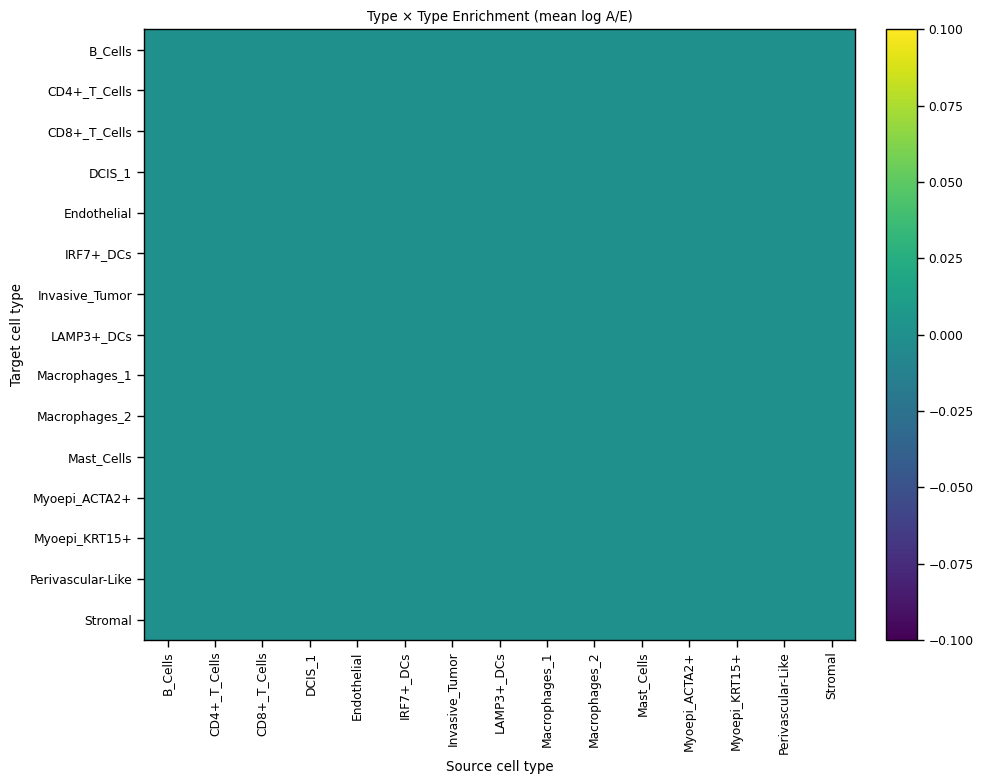

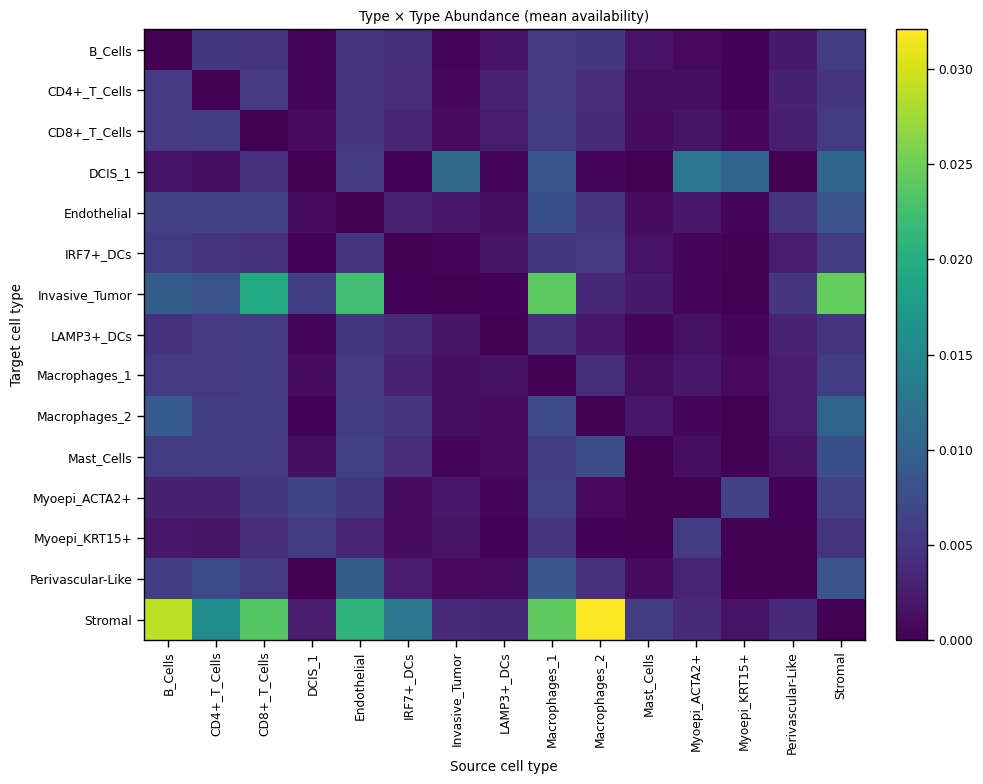

In [37]:
enrich_tt, abun_tt = plot_type_type_heatmaps(
    adata_ref=adata_xenium,
    cluster_key=cluster_key
)

In [31]:
adata_xenium.obsm['omega'].flatten().mean()

0.009009967

In [32]:
adata_xenium.obsm['abundance'].flatten().mean()

0.007636238

In [40]:
adata_xenium.obsm['abundance']

array([[0.01065603, 0.        , 0.00877126, ..., 0.        , 0.01065433,
        0.        ],
       [0.03457482, 0.        , 0.02773881, ..., 0.        , 0.03407771,
        0.03347948],
       [0.03235278, 0.        , 0.02514395, ..., 0.        , 0.03178275,
        0.02815904],
       ...,
       [0.00420398, 0.0042478 , 0.        , ..., 0.        , 0.00473771,
        0.00396198],
       [0.00337494, 0.00342983, 0.00341161, ..., 0.        , 0.00363477,
        0.00314029],
       [0.00442208, 0.        , 0.00449388, ..., 0.        , 0.00496392,
        0.0040806 ]], dtype=float32)

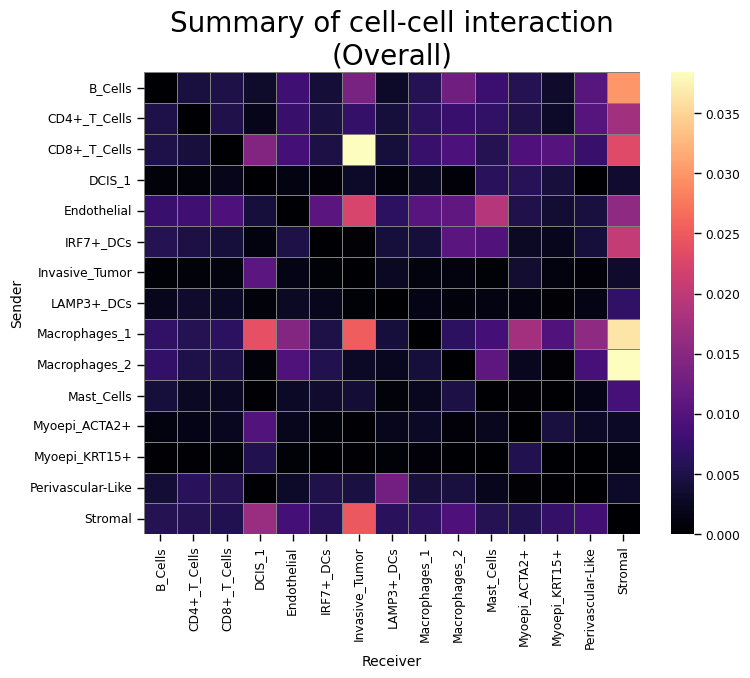

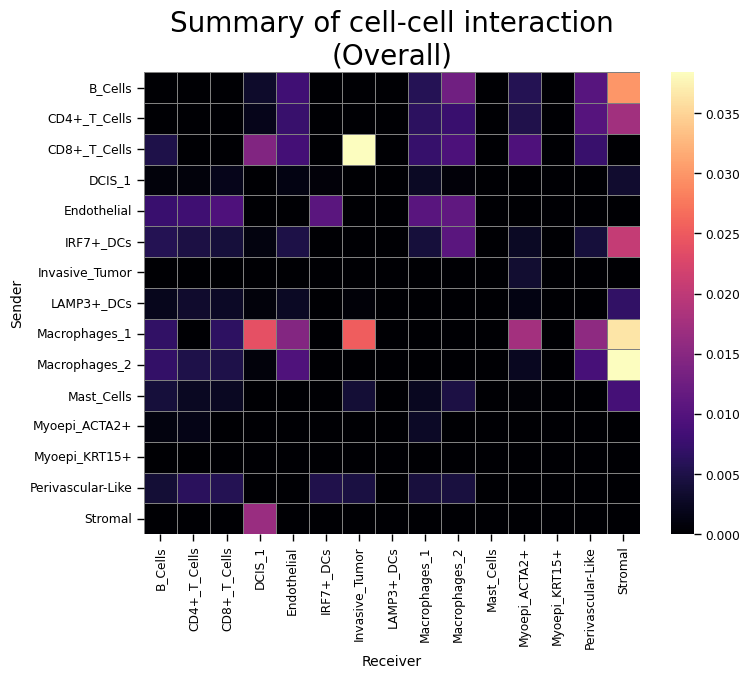

In [42]:
cluster_labels = adata_xenium.obs['cell_type'].cat.categories

rcParams["axes.grid"] = False
cci_df = plot.summarize_cell_interaction(
    adata_xenium, 
    cluster_key=cluster_key, 
    title='Summary of cell-cell interaction\n(Overall)',
    show_plot=True
)
cci_df, sig_df = test_assoc.test_cci(adata_xenium, cci_df, cluster_labels, cluster_key=cluster_key)
plot.disp_heatmap(
    cci_df,
    title='Summary of cell-cell interaction\n(Overall)'
)

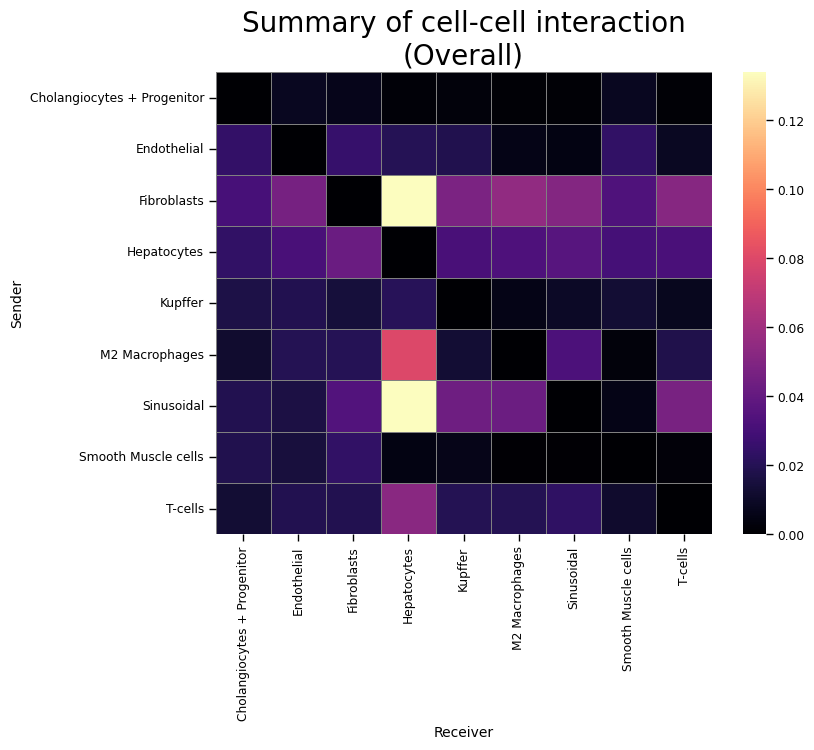

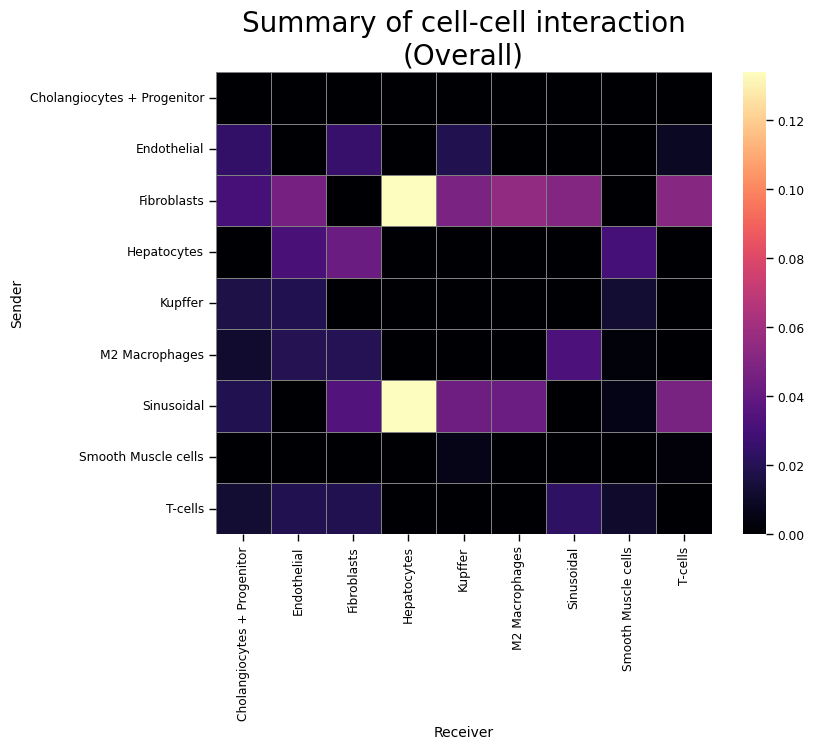

In [142]:
cluster_labels = adata_xenium.obs['cell_type'].cat.categories

rcParams["axes.grid"] = False
cci_df = plot.summarize_cell_interaction(
    adata_xenium, 
    cluster_key=cluster_key, 
    title='Summary of cell-cell interaction\n(Overall)',
    show_plot=True
)
cci_df, sig_df = test_assoc.test_cci(adata_xenium, cci_df, cluster_labels, cluster_key=cluster_key)
plot.disp_heatmap(
    cci_df,
    title='Summary of cell-cell interaction\n(Overall)'
)


# rcParams["axes.grid"] = False
# adata_dcis = adata_xenium[adata_xenium.obs['milestones'] == 'dcis'].copy()
# dcis_cci_df = plot.summarize_cell_interaction(
#     adata_dcis,
#     cluster_key=cluster_key, 
#     cluster_labels=cluster_labels,
#     title='Summary of cell-cell interaction\n(DCIS hub)',
#     show_plot=True
# )
# dcis_cci_df = test_assoc.test_cci(adata_dcis, dcis_cci_df, cluster_labels, cluster_key=cluster_key)
# plot.disp_heatmap(
#     dcis_cci_df,
#     title='Summary of cell-cell interaction\n(DCIS hub)'
# )

# rcParams["axes.grid"] = False
# adata_invasive = adata_xenium[adata_xenium.obs['milestones'] == 'invasive'].copy()
# invasive_cci_df = plot.summarize_cell_interaction(
#     adata_invasive,
#     cluster_key=cluster_key, 
#     cluster_labels=cluster_labels,
#     title='Summary of cell-cell interaction\n(Invasive Tumor hub)',
#     show_plot=True
# )
# invasive_cci_df = test_assoc.test_cci(adata_invasive, invasive_cci_df, cluster_labels, cluster_key=cluster_key)
# plot.disp_heatmap(
#     invasive_cci_df,
#     title='Summary of cell-cell interaction\n(Invasive Tumor hub)'
# )

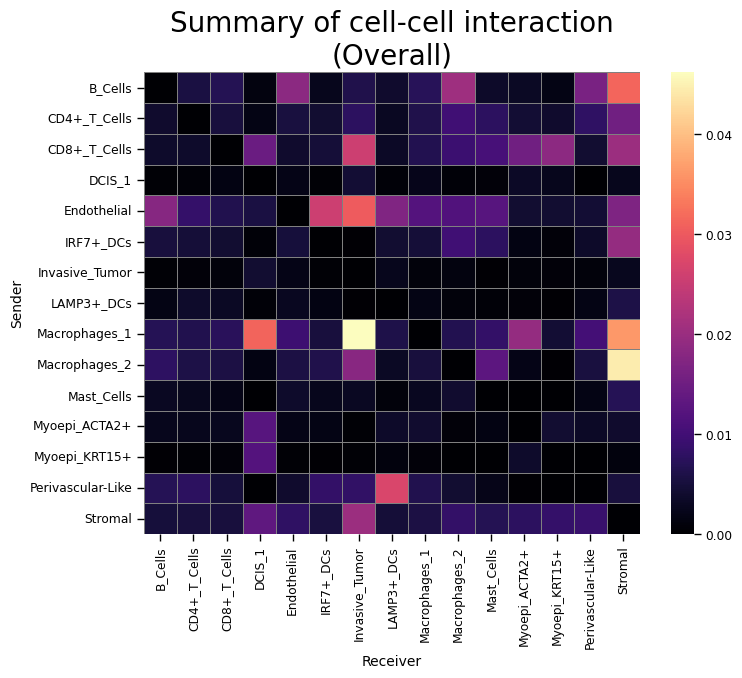

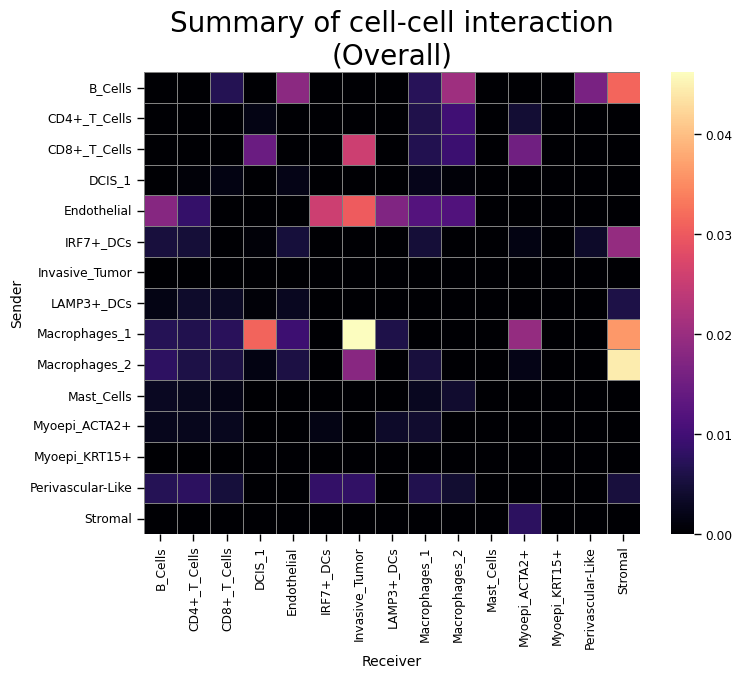

In [20]:
cluster_labels = adata_xenium.obs['cell_type'].cat.categories

rcParams["axes.grid"] = False
cci_df = plot.summarize_cell_interaction(
    adata_xenium, 
    cluster_key=cluster_key, 
    title='Summary of cell-cell interaction\n(Overall)',
    show_plot=True
)
cci_df, sig_df = test_assoc.test_cci(adata_xenium, cci_df, cluster_labels, cluster_key=cluster_key)
plot.disp_heatmap(
    cci_df,
    title='Summary of cell-cell interaction\n(Overall)'
)


# rcParams["axes.grid"] = False
# adata_dcis = adata_xenium[adata_xenium.obs['milestones'] == 'dcis'].copy()
# dcis_cci_df = plot.summarize_cell_interaction(
#     adata_dcis,
#     cluster_key=cluster_key, 
#     cluster_labels=cluster_labels,
#     title='Summary of cell-cell interaction\n(DCIS hub)',
#     show_plot=True
# )
# dcis_cci_df = test_assoc.test_cci(adata_dcis, dcis_cci_df, cluster_labels, cluster_key=cluster_key)
# plot.disp_heatmap(
#     dcis_cci_df,
#     title='Summary of cell-cell interaction\n(DCIS hub)'
# )

# rcParams["axes.grid"] = False
# adata_invasive = adata_xenium[adata_xenium.obs['milestones'] == 'invasive'].copy()
# invasive_cci_df = plot.summarize_cell_interaction(
#     adata_invasive,
#     cluster_key=cluster_key, 
#     cluster_labels=cluster_labels,
#     title='Summary of cell-cell interaction\n(Invasive Tumor hub)',
#     show_plot=True
# )
# invasive_cci_df = test_assoc.test_cci(adata_invasive, invasive_cci_df, cluster_labels, cluster_key=cluster_key)
# plot.disp_heatmap(
#     invasive_cci_df,
#     title='Summary of cell-cell interaction\n(Invasive Tumor hub)'
# )

In [ ]:
fig, ax = plot.netVisual_circle(
    dcis_cci_df, figsize=(18, 18),
    title="Summary of cell-cell interaction\n (DCIS hub)", 
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_dcis_cci.pdf'), bbox_inches='tight')

fig, ax = plot.netVisual_circle(
    invasive_cci_df, figsize=(18, 18),
    title="Summary of cell-cell interaction\n (Invasive Tumor hub)", 
)
plt.show()
# fig.savefig(os.path.join(outdir, 'LYNX_Fig4_invasive_cci.pdf'), bbox_inches='tight')


In [ ]:
indices

In [ ]:
cell_boundaries_filename = os.path.join(data_path, 'cell_boundaries.parquet')

indices = adata_xenium.obs[
    (adata_xenium.obs['cell_type'] == 'Macrophages_2') & 
    (adata_xenium.obs['milestones'] == 'dcis')
].index
for idx in indices[:3]:
    plot.disp_spatial_interaction(
        adata_xenium,
        target_idx=idx,
        cell_boundaries_parquet=cell_boundaries_filename,
    )

indices = adata_xenium.obs[
    (adata_xenium.obs['cell_type'] == 'Macrophages_2') & 
    (adata_xenium.obs['milestones'] == 'invasive')
].index
for idx in indices[:3]:
    plot.disp_spatial_interaction(
        adata_xenium,
        target_idx=idx,
        cell_boundaries_parquet=cell_boundaries_filename,
    )

del idx, indices


#### Compile figure

In [ ]:
figure_outdir = os.path.abspath("../figures/Figure_4_breast")

In [ ]:
%%bash -s $figure_outdir
cat<<'EOF' >$1.tex
\documentclass{article}
\usepackage[paperheight=270mm,paperwidth=210mm]{geometry}
\geometry{left=5mm,right=5mm,top=5mm,bottom=5mm}

\usepackage{silence}
\WarningsOff*

\usepackage[labelfont=bf]{caption}
\usepackage[rgb]{xcolor}

% Use traditional font packages so this compiles with tectonic/pdfLaTeX.
% (Removed fontspec + \setmainfont which require Xe/LuaTeX.)
\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage{helvet}
\renewcommand{\familydefault}{\sfdefault}

\usepackage{graphicx}
\usepackage[export]{adjustbox}

% Allow underscores and more flexible graphics filenames
\usepackage{grffile}   % handles multiple dots/complex filenames
\usepackage{underscore}

\begin{document}

\noindent
\fontsize{11pt}{11pt}\selectfont

% ===== Panel A =====
\begin{minipage}[t]{0.5\textwidth}
\textbf{a}\\[0.5mm]
\includegraphics[width=0.9\textwidth]{LYNX_Fig4_spatial.pdf}
\end{minipage}\hfill%
%
% ===== Panel B =====
\begin{minipage}[t]{0.5\textwidth}
\textbf{b}\\[0.5mm]
\includegraphics[width=0.45\textwidth]{LYNX_Fig4_spatial_pseudotime.pdf}
\includegraphics[width=0.45\textwidth]{LYNX_Fig4_pc_pseudotime.pdf}
\end{minipage}

% ===== Panel C =====
\begin{minipage}[t]{0.5\textwidth}
\textbf{c}\\[-0.3mm]
\includegraphics[width=0.53\textwidth]{LYNX_Fig4_pc_immune.pdf}
\includegraphics[width=0.4\textwidth]{LYNX_Fig4_pc_tumor.pdf}
\end{minipage}
% ===== Panel D&E =====
\begin{minipage}[t]{0.205\textwidth}
\textbf{d}\\[1mm]
\includegraphics[width=\textwidth]{LYNX_Fig4_pc_tree.pdf}
\end{minipage}
\begin{minipage}[t]{0.245\textwidth}
\textbf{e}\\[1mm]
\includegraphics[width=\textwidth]{LYNX_Fig4_pc_hub.pdf}
\end{minipage}

% ===== Panel F =====
\begin{minipage}[t]{0.45\textwidth}
\textbf{f}\\
\includegraphics[width=\textwidth]{LYNX_Fig4_stromal_marker_heatmap.pdf}
% ===== Panel H =====
\textbf{g}\\
\includegraphics[width=0.48\textwidth]{LYNX_Fig4_gjb2_dynamics.pdf}
\includegraphics[width=0.48\textwidth]{LYNX_Fig4_sfrp4_dynamics.pdf}
\hfill

% ===== Panel G =====
\textbf{h}\\
\includegraphics[width=0.48\textwidth]{LYNX_Fig4_cd8_dynamics.pdf}
\includegraphics[width=0.48\textwidth]{LYNX_Fig4_m2_dynamics.pdf}
\end{minipage}
%
\hspace{2em}
\begin{minipage}[t]{0.55\textwidth}
\textbf{i}\\
\includegraphics[width=0.9\textwidth]{LYNX_Fig4_invasive_cci.pdf}
\end{minipage}

\end{document}
EOF

/snap/bin/tectonic -c minimal $1.tex
